# MIS5308 Week 3 PBL – PulseWear multi-layer network analysis & A/B test sizing
Notebook version of `week3_analysis.py`. Figures are displayed inline and saved to `figures/`; tables are saved to `results/`.

In [1]:
import math
import numpy as np
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd
from networkx.algorithms.community import louvain_communities, modularity
from scipy.stats import norm

HERE = Path.cwd()
FIG, RES = HERE / "figures", HERE / "results"
FIG.mkdir(exist_ok=True); RES.mkdir(exist_ok=True)

xl = pd.read_excel(HERE / "Week3_Dataset.xlsx", sheet_name=None)
inf, net, camp = xl["Influencers"], xl["Network"], xl["Campaign"]

PLAT_COL = {"Instagram": "#2a78d6", "Twitter": "#eb6834", "LinkedIn": "#1baf7a"}
INK, MUTED, GRID = "#1f1f1e", "#6b6a64", "#d9d8d2"
plt.rcParams.update({"font.family": "DejaVu Sans", "font.size": 10,
                     "axes.edgecolor": GRID, "axes.labelcolor": INK,
                     "xtick.color": MUTED, "ytick.color": MUTED})
%matplotlib inline

## 1. graphs

In [2]:
G = nx.Graph()  # undirected aggregate (supra) graph for centrality/communities
for _, r in inf.iterrows():
    G.add_node(r.Influencer, platform=r.Platform)
for _, r in net.iterrows():
    G.add_edge(r.Source, r.Target, weight=r.Weight, layer=r.Platform,
               itype=r["Interaction Type"], dist=1 / r.Weight)
D = nx.DiGraph()
D.add_weighted_edges_from(net[["Source", "Target", "Weight"]].itertuples(index=False))

layers = {p: G.edge_subgraph([(u, v) for u, v, d in G.edges(data=True) if d["layer"] == p]).copy()
          for p in ["Instagram", "Twitter", "LinkedIn"]}

## 2. centrality

In [3]:
m = pd.DataFrame(index=list(G.nodes))
m["platform"] = pd.Series(nx.get_node_attributes(G, "platform"))
m["degree"] = pd.Series(dict(G.degree()))
m["weighted_degree"] = pd.Series(dict(G.degree(weight="weight")))
m["in_strength"] = pd.Series(dict(D.in_degree(weight="weight")))
m["out_strength"] = pd.Series(dict(D.out_degree(weight="weight")))
m["degree_c"] = pd.Series(nx.degree_centrality(G))
m["betweenness"] = pd.Series(nx.betweenness_centrality(G, normalized=True))
m["betweenness_w"] = pd.Series(nx.betweenness_centrality(G, weight="dist", normalized=True))
m["eigenvector"] = pd.Series(nx.eigenvector_centrality(G, weight="weight", max_iter=2000))
m["closeness"] = pd.Series(nx.closeness_centrality(G))
m["pagerank"] = pd.Series(nx.pagerank(D, weight="weight"))
m["constraint"] = pd.Series(nx.constraint(G))  # Burt: low = structural-hole broker
m["articulation_point"] = m.index.isin(list(nx.articulation_points(G)))
m["cross_platform_edges"] = [sum(1 for _, _, d in G.edges(n, data=True) if d["layer"] == "Cross")
                             for n in m.index]

## 3. communities

In [4]:
comms = louvain_communities(G, weight="weight", seed=42)
comms = sorted(comms, key=lambda c: -len(c))
cid = {n: i for i, c in enumerate(comms) for n in c}
m["community"] = pd.Series(cid)
Q = modularity(G, comms, weight="weight")
# participation coefficient (Guimera & Amaral): share of ties spread across communities
def participation(n):
    k = G.degree(n, weight="weight")
    return 1 - sum((sum(G[n][v]["weight"] for v in G[n] if cid[v] == c) / k) ** 2
                   for c in range(len(comms)))
m["participation"] = pd.Series({n: participation(n) for n in G})
bridges = [tuple(sorted(e)) for e in nx.bridges(G)]

## 4. campaign efficiency

In [5]:
c = camp.merge(inf[["Influencer", "Followers", "Engagement Rate"]], on="Influencer")
# Assumption: CTR = clicks / followers reached; CR = purchases / clicks
c["est_clicks"] = c.Followers * c["Click-Through Rate"]
c["est_conversions"] = c.est_clicks * c["Conversion Rate"]
c["cost_per_conversion"] = c["Cost per Post (USD)"] / c.est_conversions
c["conv_per_1k_usd"] = c.est_conversions / c["Cost per Post (USD)"] * 1000
best = c.sort_values("cost_per_conversion").groupby("Influencer").first()
m = m.join(inf.set_index("Influencer")).join(
    best[["Content Type", "cost_per_conversion", "Conversion Rate"]].rename(
        columns={"Content Type": "best_format"}))

## 5. decision matrix

In [6]:
# Brand fit scored 1-5 against assumed PulseWear identity: innovative, health/performance,
# credible & data-driven, premium, positive. (Assumption - no guideline document supplied.)
brand_fit = {"TechNova": 4, "FitSara": 5, "DrWearable": 4, "GadgetGuyX": 2, "ZenLife": 3,
             "PulseGuru": 4, "ProCoach": 4, "RunSmart": 5, "DataDev": 3, "HealthInsider": 5}
m["brand_fit"] = pd.Series(brand_fit)

def minmax(s, invert=False):
    s = s.astype(float)
    x = (s - s.min()) / (s.max() - s.min())
    return 1 - x if invert else x

cpc = m.cost_per_conversion.fillna(m.cost_per_conversion.max())  # untested -> worst
score = pd.DataFrame({
    "Reach (15%)": minmax(m.Followers),
    "Engagement (15%)": minmax(m["Engagement Rate"]),
    "Network influence (20%)": (minmax(m.eigenvector) + minmax(m.pagerank)) / 2,
    "Bridging (15%)": (minmax(m.betweenness_w) + minmax(m.participation)) / 2,
    "Brand fit (20%)": minmax(m.brand_fit),
    "Cost efficiency (15%)": minmax(cpc, invert=True),
})
weights = [.15, .15, .20, .15, .20, .15]
m["suitability"] = (score * weights).sum(axis=1) * 100
score["Suitability (0-100)"] = m.suitability
score = score.sort_values("Suitability (0-100)", ascending=False)

## 6. A/B sample size

In [7]:
def n_per_arm(p1, p2, alpha=.05, power=.80):
    za, zb = norm.ppf(1 - alpha / 2), norm.ppf(power)
    pbar = (p1 + p2) / 2
    return math.ceil((za * math.sqrt(2 * pbar * (1 - pbar)) +
                      zb * math.sqrt(p1 * (1 - p1) + p2 * (1 - p2))) ** 2 / (p1 - p2) ** 2)

base_cr = (c.est_conversions.sum() / c.est_clicks.sum())
sizing = []
for lift in (.20, .30, .50):
    n = n_per_arm(base_cr, base_cr * (1 + lift))
    for icc in (0, .01):
        m_cluster = 2000  # clicks per influencer-post cluster
        deff = 1 + (m_cluster - 1) * icc
        sizing.append({"baseline_CR": round(base_cr, 4), "MDE_relative_lift": lift,
                       "ICC": icc, "design_effect": deff, "clicks_per_arm": math.ceil(n * deff)})
sizing = pd.DataFrame(sizing)

## Save tables

In [8]:
m.round(3).to_csv(RES / "node_metrics.csv")
score.round(3).to_csv(RES / "decision_matrix.csv")
c.round(3).to_csv(RES / "campaign_efficiency.csv", index=False)
sizing.to_csv(RES / "ab_sample_size.csv", index=False)

## Figures

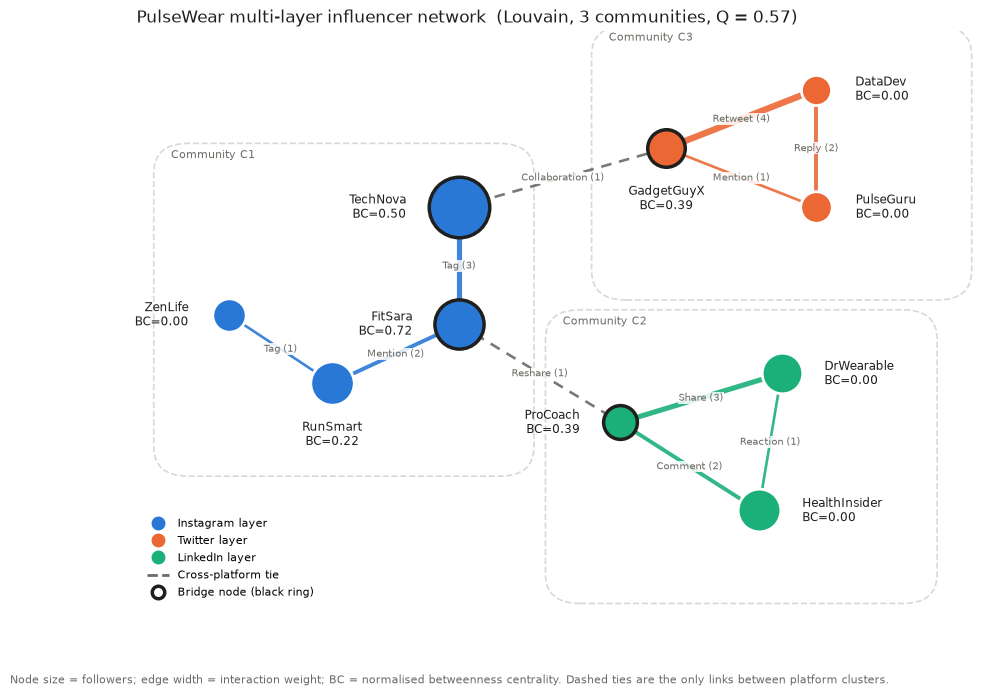

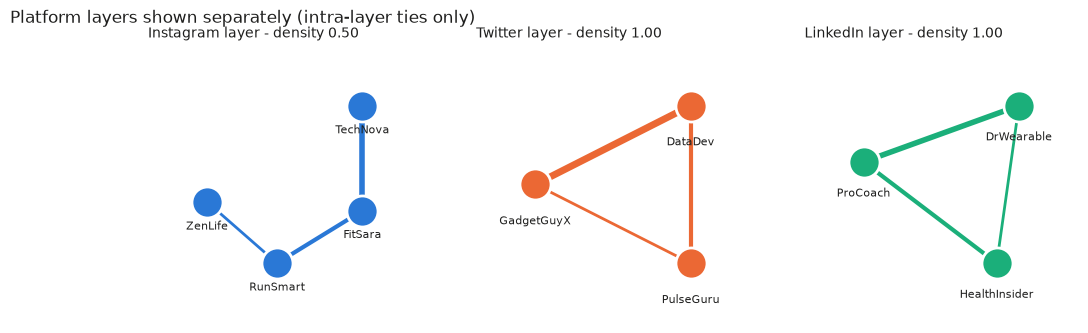

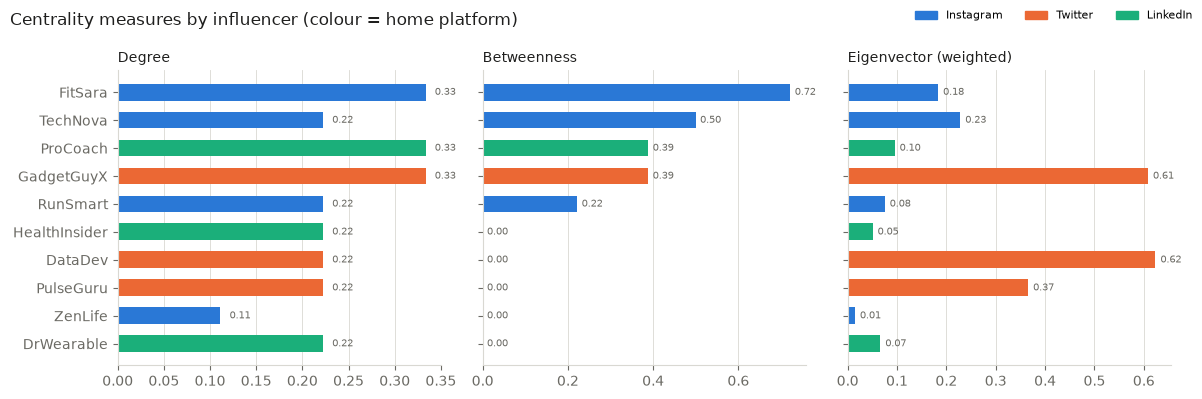

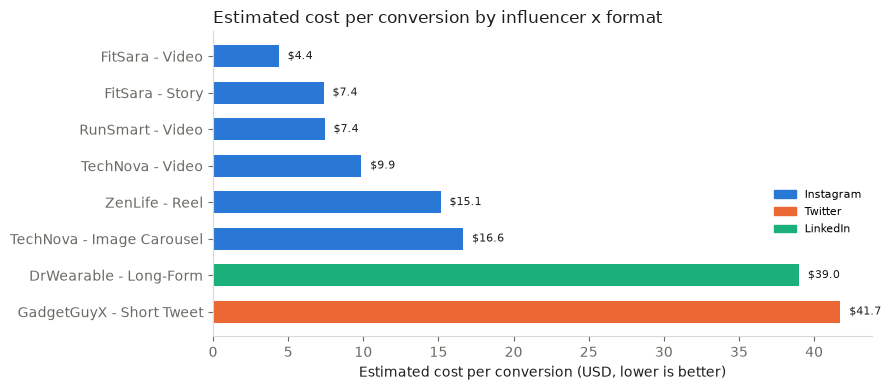

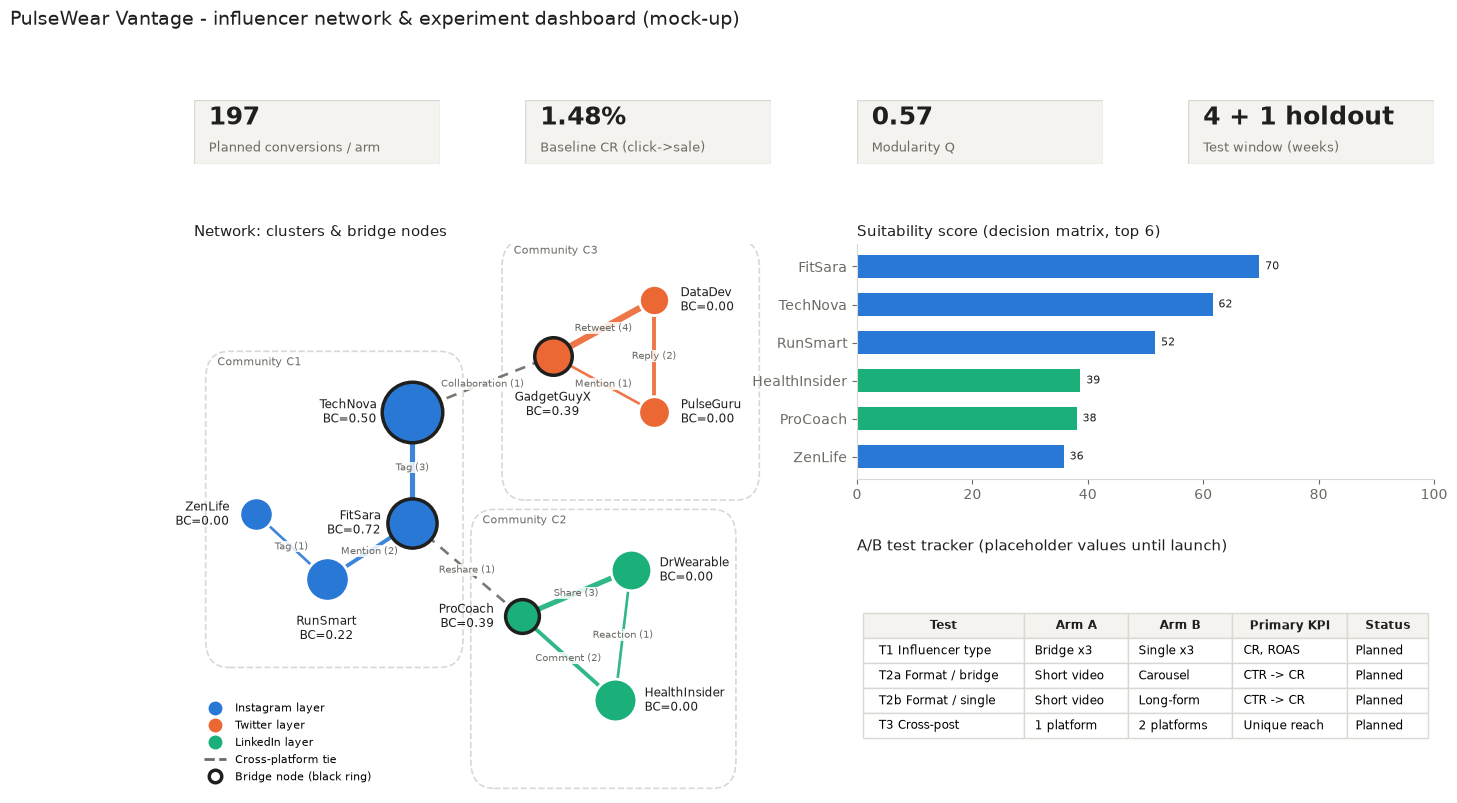

In [9]:
pos = {"TechNova": (-0.2, 0.9), "FitSara": (-0.2, -0.3), "RunSmart": (-1.3, -0.9),
       "ZenLife": (-2.2, -0.2), "GadgetGuyX": (1.6, 1.5), "DataDev": (2.9, 2.1),
       "PulseGuru": (2.9, 0.9), "ProCoach": (1.2, -1.3), "HealthInsider": (2.4, -2.2),
       "DrWearable": (2.6, -0.8)}
# label side per node (l/r/b) so text never sits on an edge
LSIDE = {"TechNova": "l", "FitSara": "l", "RunSmart": "b", "ZenLife": "l", "GadgetGuyX": "b",
         "DataDev": "r", "PulseGuru": "r", "ProCoach": "l", "HealthInsider": "r", "DrWearable": "r"}

def draw_network(ax):
    for (u, v, d) in G.edges(data=True):
        cross = d["layer"] == "Cross"
        ax.plot(*zip(pos[u], pos[v]), color=MUTED if cross else PLAT_COL[d["layer"]],
                lw=1 + d["weight"] * 0.9, ls=(0, (4, 3)) if cross else "-",
                alpha=.9, zorder=1, solid_capstyle="round")
        mx, my = (pos[u][0] + pos[v][0]) / 2, (pos[u][1] + pos[v][1]) / 2
        ax.text(mx, my, f"{d['itype']} ({d['weight']})", fontsize=7, color=MUTED,
                ha="center", va="center", zorder=2,
                bbox=dict(fc="white", ec="none", pad=.5, alpha=.85))
    for n in G:
        x, y = pos[n]
        size = 300 + m.loc[n, "Followers"] / 520000 * 1600
        br = m.loc[n, "cross_platform_edges"] > 0
        ax.scatter(x, y, s=size, color=PLAT_COL[m.loc[n, "platform"]], zorder=3,
                   edgecolors=INK if br else "white", linewidths=2.5 if br else 2)
        off = .3 + size / 12000
        lx, ly, ha, va = {"l": (x - off, y, "right", "center"), "r": (x + off, y, "left", "center"),
                          "b": (x, y - off, "center", "top")}[LSIDE[n]]
        ax.text(lx, ly, f"{n}\nBC={m.loc[n,'betweenness']:.2f}",
                ha=ha, va=va, fontsize=8.5, color=INK, zorder=4)
    for i, cset in enumerate(comms):
        xs, ys = zip(*[pos[n] for n in cset])
        ax.add_patch(plt.matplotlib.patches.FancyBboxPatch(
            (min(xs) - .6, min(ys) - .9),
            max(xs) - min(xs) + (1.9 if any(LSIDE[n] == "r" for n in cset) else 1.2), max(ys) - min(ys) + 1.5,
            boxstyle="round,pad=0.05,rounding_size=0.3", fc="none", ec=GRID, lw=1.2,
            ls="--", zorder=0))
        ax.text(min(xs) - .5, max(ys) + .5, f"Community C{i+1}", fontsize=8, color=MUTED)
    handles = [plt.Line2D([], [], marker="o", ls="", color=col, ms=9, label=f"{p} layer")
               for p, col in PLAT_COL.items()]
    handles += [plt.Line2D([], [], color=MUTED, ls="--", lw=2, label="Cross-platform tie"),
                plt.Line2D([], [], marker="o", ls="", mfc="white", mec=INK, mew=2.5, ms=9,
                           label="Bridge node (black ring)")]
    ax.legend(handles=handles, loc="lower left", frameon=False, fontsize=8)
    ax.set_xlim(-3, 4.4); ax.set_ylim(-3.2, 2.7); ax.axis("off")

fig, ax = plt.subplots(figsize=(11, 7.5))
draw_network(ax)
ax.set_title(f"PulseWear multi-layer influencer network  "
             f"(Louvain, {len(comms)} communities, Q = {Q:.2f})",
             loc="left", fontsize=12, color=INK)
fig.text(.01, .01, "Node size = followers; edge width = interaction weight; BC = normalised "
         "betweenness centrality. Dashed ties are the only links between platform clusters.",
         fontsize=8, color=MUTED)
fig.savefig(FIG / "fig1_multilayer_network.png", dpi=200, bbox_inches="tight"); plt.show()

# Fig 2: per-layer small multiples
fig, axes = plt.subplots(1, 3, figsize=(12, 3.6))
for ax, (p, L) in zip(axes, layers.items()):
    lp = {n: pos[n] for n in L}  # same positions as Figure 1 for easy comparison
    nx.draw_networkx_edges(L, lp, ax=ax, edge_color=PLAT_COL[p],
                           width=[1 + L[u][v]["weight"] for u, v in L.edges])
    nx.draw_networkx_nodes(L, lp, ax=ax, node_color=PLAT_COL[p], node_size=500,
                           edgecolors="white", linewidths=2)
    nx.draw_networkx_labels(L, {k: (x, y - .28) for k, (x, y) in lp.items()}, ax=ax,
                            font_size=8, font_color=INK)
    ax.set_title(f"{p} layer - density {nx.density(L):.2f}", fontsize=10, color=INK, loc="left")
    ax.margins(.3); ax.axis("off")
fig.suptitle("Platform layers shown separately (intra-layer ties only)",
             x=.01, ha="left", fontsize=12, color=INK)
fig.savefig(FIG / "fig2_layers.png", dpi=200, bbox_inches="tight"); plt.show()

# Fig 3: centrality comparison (small multiples, one measure each -> no dual axis)
fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=True)
order = m.sort_values("betweenness").index
for ax, (col, lab) in zip(axes, [("degree_c", "Degree"), ("betweenness", "Betweenness"),
                                 ("eigenvector", "Eigenvector (weighted)")]):
    ax.barh(order, m.loc[order, col], color=[PLAT_COL[m.loc[n, "platform"]] for n in order],
            height=.6)
    for n in order:
        ax.text(m.loc[n, col] + .01, n, f"{m.loc[n, col]:.2f}", va="center", fontsize=7.5,
                color=MUTED)
    ax.set_title(lab, loc="left", fontsize=10, color=INK)
    ax.spines[["top", "right"]].set_visible(False); ax.grid(axis="x", color=GRID, lw=.6)
    ax.set_axisbelow(True)
fig.legend(handles=[plt.Rectangle((0, 0), 1, 1, color=v, label=k) for k, v in PLAT_COL.items()],
           frameon=False, fontsize=8, loc="upper right", ncol=3)
fig.suptitle("Centrality measures by influencer (colour = home platform)",
             x=.01, ha="left", fontsize=12, color=INK)
fig.tight_layout(); fig.savefig(FIG / "fig3_centrality.png", dpi=200, bbox_inches="tight")
plt.show()

# Fig 4: cost per conversion
cc = c.sort_values("cost_per_conversion")
fig, ax = plt.subplots(figsize=(9, 4))
labels = cc.Influencer + " - " + cc["Content Type"]
ax.barh(labels, cc.cost_per_conversion, color=[PLAT_COL[m.loc[n, "platform"]] for n in cc.Influencer],
        height=.6)
for y, v in enumerate(cc.cost_per_conversion):
    ax.text(v + .6, y, f"${v:,.1f}", va="center", fontsize=8, color=INK)
ax.invert_yaxis(); ax.spines[["top", "right"]].set_visible(False)
ax.legend(handles=[plt.Rectangle((0, 0), 1, 1, color=v, label=k) for k, v in PLAT_COL.items()],
          frameon=False, fontsize=8, loc="lower right", bbox_to_anchor=(1, .3))
ax.set_xlabel("Estimated cost per conversion (USD, lower is better)")
ax.set_title("Estimated cost per conversion by influencer x format",
             loc="left", fontsize=12, color=INK)
fig.tight_layout(); fig.savefig(FIG / "fig4_cost_per_conversion.png", dpi=200); plt.show()

# Fig 5: dashboard mock-up
fig = plt.figure(figsize=(16, 9))
gs = fig.add_gridspec(3, 4, height_ratios=[.55, 2, 2], hspace=.45, wspace=.35)
kpis = [("Planned conversions / arm", f"{int(sizing.query('MDE_relative_lift==0.3 and ICC==0').clicks_per_arm.iloc[0] * base_cr):,}"),
        ("Baseline CR (click->sale)", f"{base_cr:.2%}"),
        ("Modularity Q", f"{Q:.2f}"),
        ("Test window (weeks)", "4 + 1 holdout")]
for i, (k, v) in enumerate(kpis):
    ax = fig.add_subplot(gs[0, i]); ax.axis("off")
    ax.add_patch(plt.Rectangle((0, 0), 1, 1, transform=ax.transAxes, fc="#f4f3ef", ec=GRID))
    ax.text(.06, .62, v, fontsize=18, color=INK, transform=ax.transAxes, weight="bold")
    ax.text(.06, .2, k, fontsize=9, color=MUTED, transform=ax.transAxes)
ax = fig.add_subplot(gs[1:, :2]); draw_network(ax)
ax.set_title("Network: clusters & bridge nodes", loc="left", fontsize=11, color=INK)
ax = fig.add_subplot(gs[1, 2:])
top = score.head(6)["Suitability (0-100)"][::-1]
ax.barh(top.index, top.values, color=[PLAT_COL[m.loc[n, "platform"]] for n in top.index], height=.6)
for y, v in enumerate(top.values):
    ax.text(v + 1, y, f"{v:.0f}", va="center", fontsize=8, color=INK)
ax.set_xlim(0, 100); ax.spines[["top", "right"]].set_visible(False)
ax.set_title("Suitability score (decision matrix, top 6)", loc="left", fontsize=11, color=INK)
ax = fig.add_subplot(gs[2, 2:]); ax.axis("off")
ax.set_title("A/B test tracker (placeholder values until launch)", loc="left", fontsize=11, color=INK)
rows = [["Test", "Arm A", "Arm B", "Primary KPI", "Status"],
        ["T1 Influencer type", "Bridge x3", "Single x3", "CR, ROAS", "Planned"],
        ["T2a Format / bridge", "Short video", "Carousel", "CTR -> CR", "Planned"],
        ["T2b Format / single", "Short video", "Long-form", "CTR -> CR", "Planned"],
        ["T3 Cross-post", "1 platform", "2 platforms", "Unique reach", "Planned"]]
t = ax.table(cellText=rows[1:], colLabels=rows[0], loc="center", cellLoc="left",
             colWidths=[.28, .18, .18, .2, .14])
t.auto_set_font_size(False); t.set_fontsize(8.5); t.scale(1, 1.5)
for (r, _), cell in t.get_celld().items():
    cell.set_edgecolor(GRID)
    if r == 0: cell.set_text_props(weight="bold", color=INK); cell.set_facecolor("#f4f3ef")
fig.suptitle("PulseWear Vantage - influencer network & experiment dashboard (mock-up)",
             x=.01, ha="left", fontsize=14, color=INK)
fig.savefig(FIG / "fig5_dashboard_mockup.png", dpi=170, bbox_inches="tight"); plt.show()

## Console summary

In [10]:
pd.set_option("display.width", 200)
print("Communities:", [sorted(x) for x in comms], "Q =", round(Q, 3))
print("Bridge edges:", bridges)
print(m[["platform", "degree", "weighted_degree", "betweenness", "betweenness_w", "eigenvector",
         "pagerank", "constraint", "participation", "articulation_point", "community"]]
      .sort_values("betweenness", ascending=False).round(3))
print(c[["Influencer", "Content Type", "est_clicks", "est_conversions", "cost_per_conversion"]].round(2))
print(score.round(2))
print(sizing)

Communities: [['FitSara', 'RunSmart', 'TechNova', 'ZenLife'], ['DrWearable', 'HealthInsider', 'ProCoach'], ['DataDev', 'GadgetGuyX', 'PulseGuru']] Q = 0.57
Bridge edges: [('FitSara', 'TechNova'), ('GadgetGuyX', 'TechNova'), ('FitSara', 'RunSmart'), ('FitSara', 'ProCoach'), ('RunSmart', 'ZenLife')]
                platform  degree  weighted_degree  betweenness  betweenness_w  eigenvector  pagerank  constraint  participation  articulation_point  community
FitSara        Instagram       3                6        0.722          0.722        0.183     0.032       0.333          0.278                True          0
TechNova       Instagram       2                4        0.500          0.500        0.228     0.019       0.500          0.375                True          0
GadgetGuyX       Twitter       3                6        0.389          0.389        0.608     0.140       0.611          0.278                True          2
ProCoach        LinkedIn       3                6        0.389   

## Additional figures for the appendix

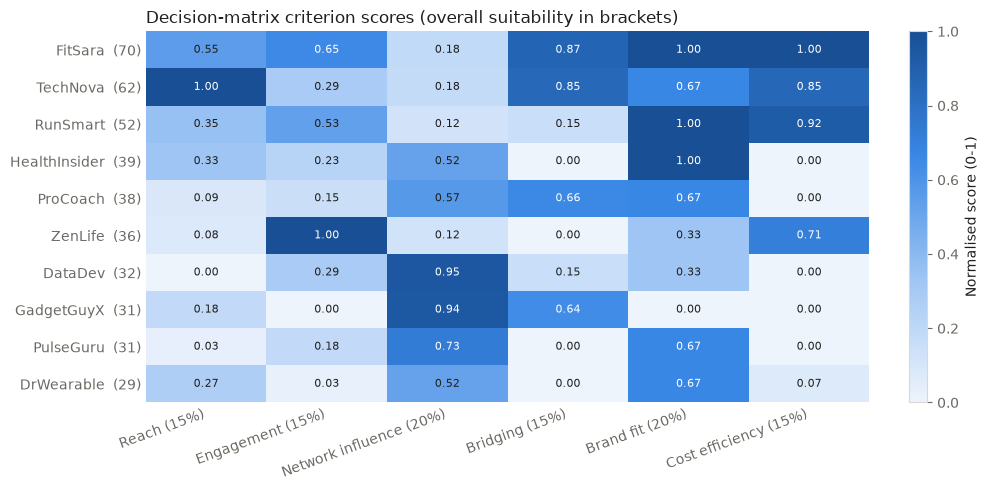

In [11]:
# Figure A-heatmap: decision-matrix criterion scores (sequential, one hue)
from matplotlib.colors import LinearSegmentedColormap
crit = score.drop(columns="Suitability (0-100)")
cmap = LinearSegmentedColormap.from_list("blue", ["#eef4fc", "#9ec5f4", "#3987e5", "#184f95"])
fig, ax = plt.subplots(figsize=(10, 5))
im = ax.imshow(crit.values, cmap=cmap, vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(crit.shape[1]), crit.columns, rotation=20, ha="right")
ax.set_yticks(range(len(crit)), [f"{n}  ({s:.0f})" for n, s in score["Suitability (0-100)"].items()])
for (r, k), v in np.ndenumerate(crit.values):
    ax.text(k, r, f"{v:.2f}", ha="center", va="center", fontsize=8,
            color="white" if v > .6 else INK)
ax.tick_params(length=0); [s.set_visible(False) for s in ax.spines.values()]
fig.colorbar(im, ax=ax, fraction=.03, label="Normalised score (0-1)")
ax.set_title("Decision-matrix criterion scores (overall suitability in brackets)",
             loc="left", fontsize=12, color=INK)
fig.tight_layout(); fig.savefig(FIG / "figA4_decision_heatmap.png", dpi=200); plt.show()

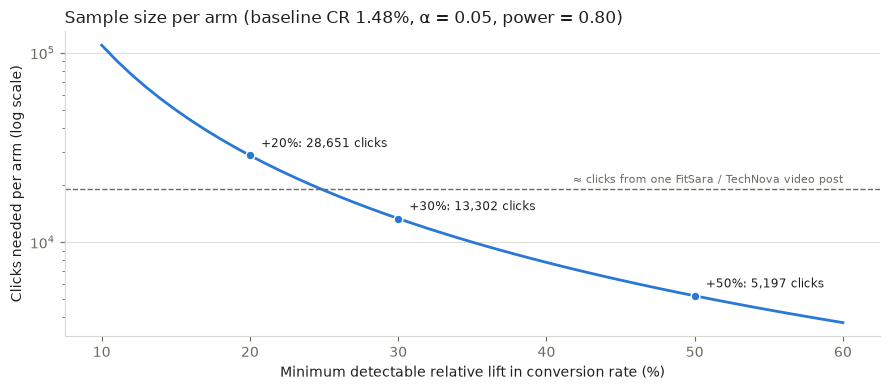

In [12]:
# Figure A-power: clicks needed per arm vs minimum detectable lift
lifts = np.linspace(.10, .60, 51)
need = [n_per_arm(base_cr, base_cr * (1 + l)) for l in lifts]
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(lifts * 100, need, color="#2a78d6", lw=2)
for l in (.2, .3, .5):
    n = n_per_arm(base_cr, base_cr * (1 + l))
    ax.scatter(l * 100, n, s=40, color="#2a78d6", edgecolors="white", zorder=3)
    ax.annotate(f"+{l:.0%}: {n:,} clicks", (l * 100, n), xytext=(8, 6),
                textcoords="offset points", fontsize=8.5, color=INK)
ax.axhline(19000, color=MUTED, ls="--", lw=1)
ax.text(60, 19000 * 1.08, "≈ clicks from one FitSara / TechNova video post", ha="right",
        fontsize=8, color=MUTED)
ax.set_yscale("log"); ax.set_xlabel("Minimum detectable relative lift in conversion rate (%)")
ax.set_ylabel("Clicks needed per arm (log scale)")
ax.spines[["top", "right"]].set_visible(False); ax.grid(axis="y", color=GRID, lw=.6)
ax.set_title(f"Sample size per arm (baseline CR {base_cr:.2%}, α = 0.05, power = 0.80)",
             loc="left", fontsize=12, color=INK)
fig.tight_layout(); fig.savefig(FIG / "figA5_sample_size_curve.png", dpi=200); plt.show()